<h1>Model Fitting</h1>

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

In [29]:
preprocessed = pd.read_csv('preprocessed_data.csv')
print(f'Loaded shape: {preprocessed.shape}')

train_df = preprocessed[preprocessed['_split'] == 'train'].drop('_split', axis=1)
test_df  = preprocessed[preprocessed['_split'] == 'test'].drop('_split',  axis=1)

X_train = train_df.drop('TenYearCHD', axis=1)
y_train = train_df['TenYearCHD']
X_test  = test_df.drop('TenYearCHD', axis=1)
y_test  = test_df['TenYearCHD']

print(f'Train : {X_train.shape[0]} samples | Test : {X_test.shape[0]} samples')
print(f'Features: {X_train.shape[1]}')
print(f'Train target balance: {y_train.value_counts().to_dict()}')
print(f'Test  target balance: {y_test.value_counts().to_dict()}')

Loaded shape: (5353, 24)
Train : 4282 samples | Test : 1071 samples
Features: 22
Train target balance: {0: 2855, 1: 1427}
Test  target balance: {0: 714, 1: 357}


# Model Selection
- It is Binary Classification problem so we use Logistic Regression, Random Forest, Decision Tree, SVM ,KNN

<h4>Logistic Regression</h4>

In [30]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,recall_score, f1_score,precision_score
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(X_train,y_train)

LogisticRegression()

Accuracy: 0.711484593837535
precision:  0.6025641025641025
Recall:  0.3949579831932773
F1-score:  0.47715736040609136

 confusion matrix:


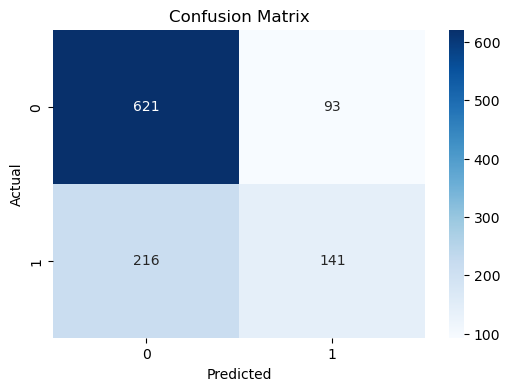

              precision    recall  f1-score   support

           0       0.74      0.87      0.80       714
           1       0.60      0.39      0.48       357

    accuracy                           0.71      1071
   macro avg       0.67      0.63      0.64      1071
weighted avg       0.70      0.71      0.69      1071



In [31]:
y_pred=lr.predict(X_test)
accLR=accuracy_score(y_test,y_pred)
precision_LR=precision_score(y_test,y_pred)
recall_LR=recall_score(y_test,y_pred)
f1_LR=f1_score(y_test,y_pred)
print("Accuracy:",accLR)
print("precision: ",precision_LR)
print("Recall: ",recall_LR)
print("F1-score: ",f1_LR)
print("\n confusion matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
print(classification_report(y_test,y_pred))

<h4>Random Forest</h4>

In [32]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

Accuracy: 0.9495798319327731
precision:  0.9316239316239316
Recall:  0.9159663865546218
F1-score:  0.923728813559322


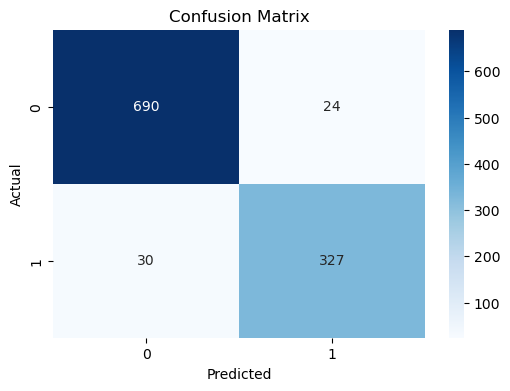

 classfication report

              precision    recall  f1-score   support

           0       0.96      0.97      0.96       714
           1       0.93      0.92      0.92       357

    accuracy                           0.95      1071
   macro avg       0.94      0.94      0.94      1071
weighted avg       0.95      0.95      0.95      1071



In [33]:
y_pred=model.predict(X_test)
accRF=accuracy_score(y_test,y_pred)
precision_RF=precision_score(y_test,y_pred)
recall_RF=recall_score(y_test,y_pred)
f1_RF=f1_score(y_test,y_pred)

print("Accuracy:",accRF)
print("precision: ",precision_RF)
print("Recall: ",recall_RF)
print("F1-score: ",f1_RF)

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
print(" classfication report\n")
print(classification_report(y_test,y_pred))

<h4>Desicion Tree</h4>

In [34]:
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

Accuracy: 0.8832866479925303
precision:  0.7723004694835681
Recall:  0.9215686274509803
F1-score:  0.8403575989782887

 confusion matrix:


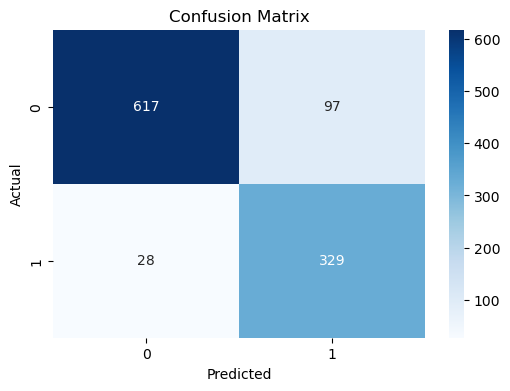

              precision    recall  f1-score   support

           0       0.96      0.86      0.91       714
           1       0.77      0.92      0.84       357

    accuracy                           0.88      1071
   macro avg       0.86      0.89      0.87      1071
weighted avg       0.90      0.88      0.89      1071



In [35]:
y_pred=model.predict(X_test)
accDT=accuracy_score(y_test,y_pred)
precision_DT=precision_score(y_test,y_pred)
recall_DT=recall_score(y_test,y_pred)
f1_DT=f1_score(y_test,y_pred)
print("Accuracy:",accDT)
print("precision: ",precision_DT)
print("Recall: ",recall_DT)
print("F1-score: ",f1_DT)
print("\n confusion matrix:")
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
print(classification_report(y_test,y_pred))

<h4>SVM(support vector machine)</h4>

In [36]:
from sklearn.svm import SVC
model=SVC()
model.fit(X_train,y_train)

SVC()

Accuracy: 0.7591036414565826
precision:  0.6972111553784861
Recall:  0.49019607843137253
F1-score:  0.5756578947368421


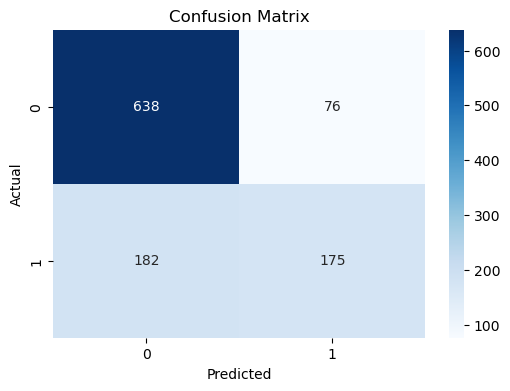

 classfication report

              precision    recall  f1-score   support

           0       0.78      0.89      0.83       714
           1       0.70      0.49      0.58       357

    accuracy                           0.76      1071
   macro avg       0.74      0.69      0.70      1071
weighted avg       0.75      0.76      0.75      1071



In [37]:
y_pred=model.predict(X_test)
accSVM=accuracy_score(y_test,y_pred)
precision_SVM=precision_score(y_test,y_pred)
recall_SVM=recall_score(y_test,y_pred)
f1_SVM=f1_score(y_test,y_pred)
print("Accuracy:",accSVM)
print("precision: ",precision_SVM)
print("Recall: ",recall_SVM)
print("F1-score: ",f1_SVM)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
print(" classfication report\n")
print(classification_report(y_test,y_pred))

<h4>K-Nearest Neighbors (KNN)</h4>

In [38]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier()
model.fit(X_train, y_train)

KNeighborsClassifier()

Accuracy: 0.7563025210084033
precision:  0.6159420289855072
Recall:  0.7142857142857143
F1-score:  0.6614785992217899


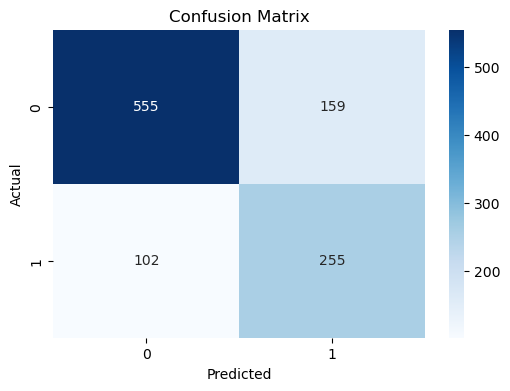

 classfication report

              precision    recall  f1-score   support

           0       0.84      0.78      0.81       714
           1       0.62      0.71      0.66       357

    accuracy                           0.76      1071
   macro avg       0.73      0.75      0.74      1071
weighted avg       0.77      0.76      0.76      1071



In [39]:
y_pred=model.predict(X_test)
accKNN=accuracy_score(y_test,y_pred)
precision_KNN=precision_score(y_test,y_pred)
recall_KNN=recall_score(y_test,y_pred)
f1_KNN=f1_score(y_test,y_pred)
print("Accuracy:",accKNN)
print("precision: ",precision_KNN)
print("Recall: ",recall_KNN)
print("F1-score: ",f1_KNN)
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()
print(" classfication report\n")
print(classification_report(y_test,y_pred))

<h3>Comparing different Models</h3>

In [40]:
print("Accuracy:")
print("LogisticRegression:",accLR)
print("RandomForest      :",accRF)
print("Decision Tree     :",accDT)
print("SVM               :",accSVM)
print("KNN               :",accKNN)

Accuracy:
LogisticRegression: 0.711484593837535
RandomForest      : 0.9495798319327731
Decision Tree     : 0.8832866479925303
SVM               : 0.7591036414565826
KNN               : 0.7563025210084033


The accuracy of Radom forest is high so we select Random Forest 

<h4>Final Model Summary</h4>

In [41]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [42]:
y_pred=model.predict(X_test)
final_acc=accuracy_score(y_test,y_pred)
final_recall=recall_score(y_test,y_pred)
final_f1=f1_score(y_test,y_pred)

print("\nEvaluation metrices:\n")

print("Accuracy : ",final_acc)
print("Recall   : ",final_recall)
print("F1-score : ",final_f1)

print("\n\n classfication report\n")
print(classification_report(y_test,y_pred))


Evaluation metrices:

Accuracy :  0.954248366013072
Recall   :  0.9187675070028011
F1-score :  0.9304964539007092


 classfication report

              precision    recall  f1-score   support

           0       0.96      0.97      0.97       714
           1       0.94      0.92      0.93       357

    accuracy                           0.95      1071
   macro avg       0.95      0.95      0.95      1071
weighted avg       0.95      0.95      0.95      1071



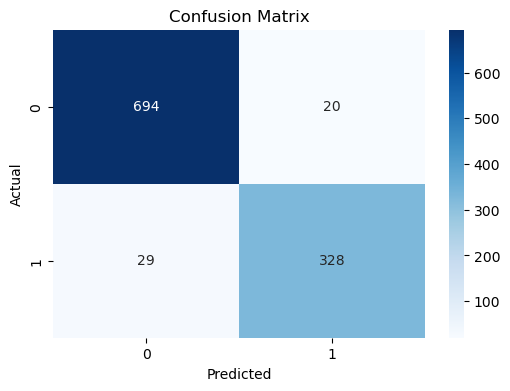

In [43]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

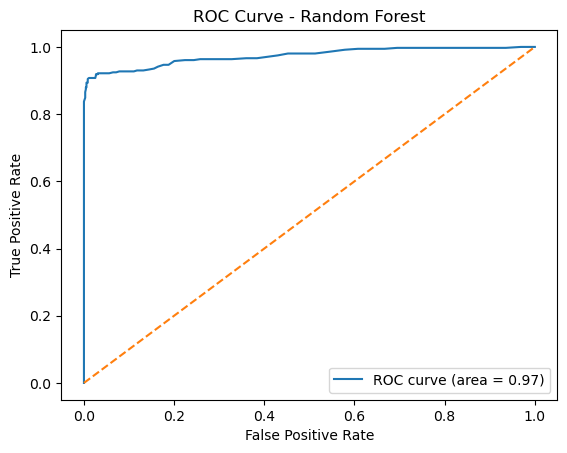

In [44]:
from sklearn.metrics import roc_curve, auc
y_probs = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)
plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend(loc="lower right")
plt.show()

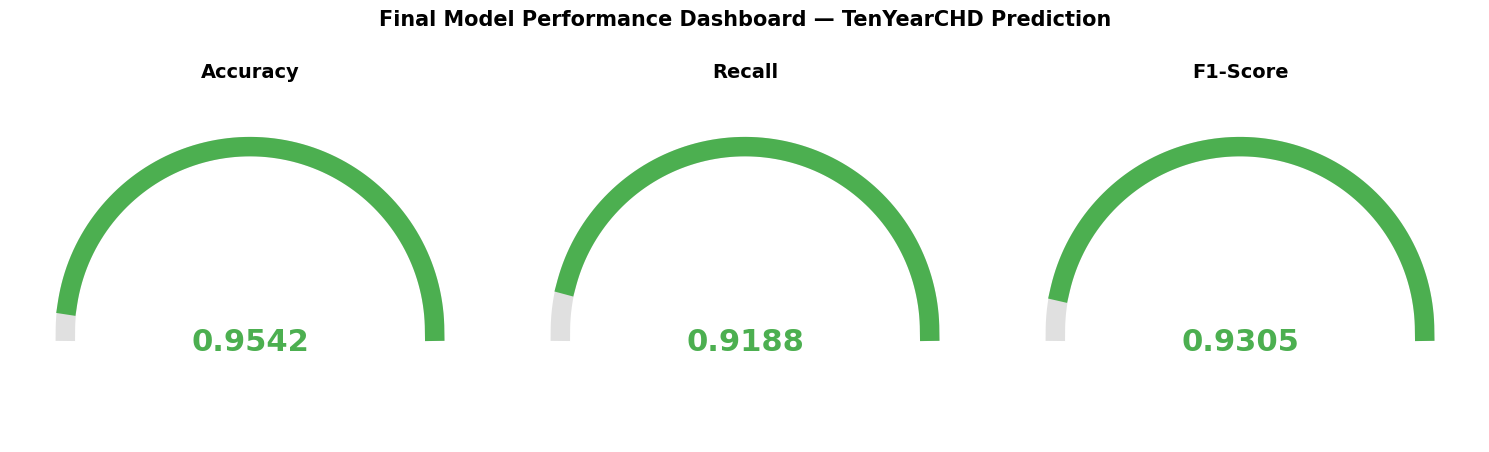

  FINAL MODEL RESULTS
  Accuracy : 0.9542
  Recall   : 0.9188
  F1-Score : 0.9305


In [45]:
metrics_info = [
    ('Accuracy',  final_acc),
    ('Recall',    final_recall),
    ('F1-Score',  final_f1),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
theta = np.linspace(0, np.pi, 200)

color = '#4CAF50'   

for ax, (name, val) in zip(axes, metrics_info):
    ax.plot(np.cos(theta), np.sin(theta), color='#E0E0E0', lw=14)
    theta_val = np.linspace(0, np.pi * min(val, 1.0), 200)
    ax.plot(np.cos(theta_val), np.sin(theta_val), color=color, lw=14)
    ax.text(0, -0.10, f'{val:.4f}', ha='center',
            fontsize=22, fontweight='bold', color=color)
    ax.set_xlim(-1.3, 1.3)
    ax.set_ylim(-0.6, 1.3)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(name, fontsize=14, fontweight='bold', pad=10)

fig.suptitle('Final Model Performance Dashboard — TenYearCHD Prediction',
             fontsize=15, fontweight='bold')

plt.tight_layout()
plt.show()

print('='*50)
print('  FINAL MODEL RESULTS')
print(f'  Accuracy : {final_acc:.4f}')
print(f'  Recall   : {final_recall:.4f}')
print(f'  F1-Score : {final_f1:.4f}')
print('='*50)

## Prediction

In [51]:
import pickle

model_data = {
    'model': model,
    'feature_columns': X_train.columns.tolist()
}

with open('framingham_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("✓ Model saved to 'framingham_model.pkl'")
print(f"  Features: {len(model_data['feature_columns'])}")

model = model_data['model']
feature_columns = model_data['feature_columns']

✓ Model saved to 'framingham_model.pkl'
  Features: 22


### Prediction For Already Scaled Data

In [52]:
def predict_new_patient(patient_data):
    df = pd.DataFrame([patient_data])

    prediction = model.predict(df)[0]
    probability = model.predict_proba(df)[0][1]
    
    return {
        'prediction': 'CHD RISK' if prediction == 1 else 'NO CHD RISK',
        'probability': probability,
        'risk_level': 'HIGH' if probability > 0.6 else 'MEDIUM' if probability > 0.3 else 'LOW'
    }

sample = X_train.iloc[0].to_dict()
result = predict_new_patient(sample)

print(f"Prediction: {result['prediction']}")
print(f"Probability: {result['probability']:.2%}")
print(f"Risk Level: {result['risk_level']}")

Prediction: NO CHD RISK
Probability: 5.00%
Risk Level: LOW


### Prediction For New Data

In [68]:
input_data = {
    'age': 45,
    'sex': 1,
    'cigsPerDay': 10,
    'BPMeds': 0,
    'prevalentStroke': 0,
    'prevalentHyp': 0,
    'diabetes': 0,
    'totChol': 230,
    'sysBP': 120,
    'diaBP': 80,
    'BMI': 25,
    'heartRate': 72,
    'glucose': 85
}


new_data = pd.DataFrame([input_data])
new_data = new_data.reindex(columns=feature_columns, fill_value=0)

In [69]:
prediction = model.predict(new_data)
probability = model.predict_proba(new_data)

print("Prediction (0 = No Risk, 1 = Risk):", prediction[0])
print("Probability of Heart Disease:", probability[0][1])

Prediction (0 = No Risk, 1 = Risk): 0
Probability of Heart Disease: 0.48
